Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [185]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [186]:
checkpoint_dir1  =  Path("../checkpoints/rtpp_20251208-221737") 
checkpoint_path1 = checkpoint_dir1/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/nhpp_20251208-165235") 
checkpoint_path2 = checkpoint_dir2/ "best_model_1.pth"

## Loading a trained model

In [187]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'mamba', 'bg_model_cfg': {'d_feature': 1, 'd_state': 64, 'd_model': 16, 'model_type': 'mamba', 'scale_init': 400.0}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20251208-221737', 'cuda_id': '0', 'dataset': 'PNR', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.06001083552837372, 'tau_min': 5.3589729986924795e-08, 'tau_max': 17.831666946411133,

In [137]:
model.bg_model = model2.bg_model

## Loading the catalog

In [138]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [139]:
catalog_ds.full_sequence

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 0.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92316, 1],
  time_series_times: [92316]
)

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

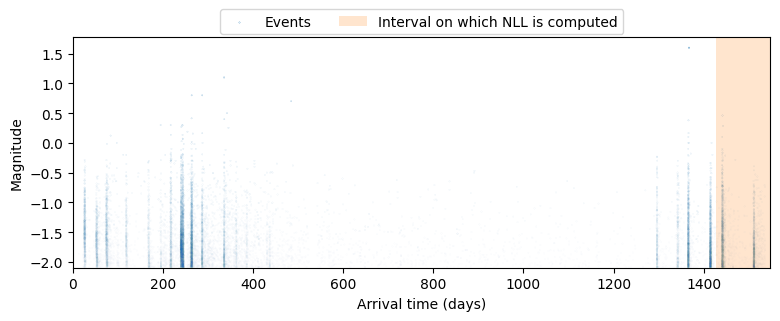

In [140]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [141]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)

Batch(
  inter_times: [1, 14869],
  arrival_times: [1, 14869],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 14869],
  input_mask: [1, 14869],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 14869],
  type_seq: [1, 14869],
  mag: [1, 14869],
  loc: [1, 14869, 2],
  depth: [1, 14869],
  time_series: [1, 54001, 1],
  time_series_times: [1, 54001]
)

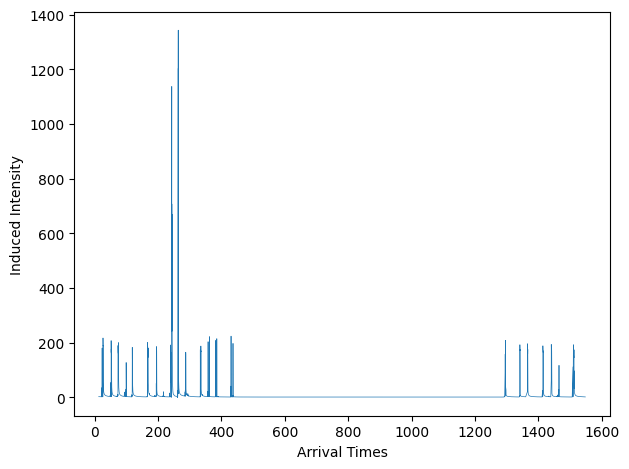

In [192]:
f_intensity= model.bg_model.intensity(test_batch)
plt.plot(
    test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),
    f_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Induced Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'induced_intensity.png')

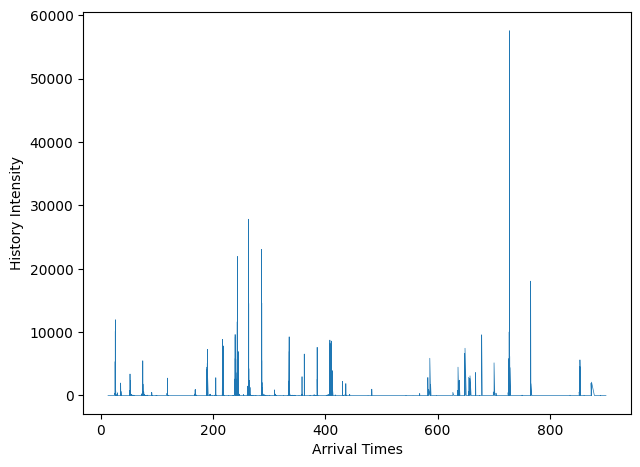

In [191]:
context = model.get_context(train_batch)
inter_time_dist = model.get_inter_time_dist(context)
log_h_intensity = inter_time_dist.log_hazard(train_batch.inter_times.clamp_min(1e-10))
h_intensity = torch.exp(log_h_intensity)
h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)
plt.xlabel('Arrival Times')
plt.ylabel('History Intensity')
plt.tight_layout()
plt.plot(train_batch.arrival_times.reshape(-1).detach().cpu().numpy(),
         h_intensity_copied.reshape(-1).detach().cpu().numpy(),
         linewidth=0.5,
         color='tab:blue')

In [193]:
(h_intensity > 1000).sum().item()

418

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [183]:
t_forecast = 1460 # 1460
duration = 20 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

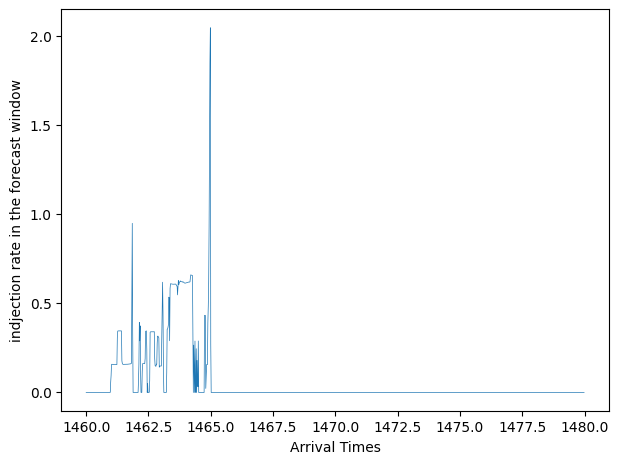

In [197]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [162]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [164]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

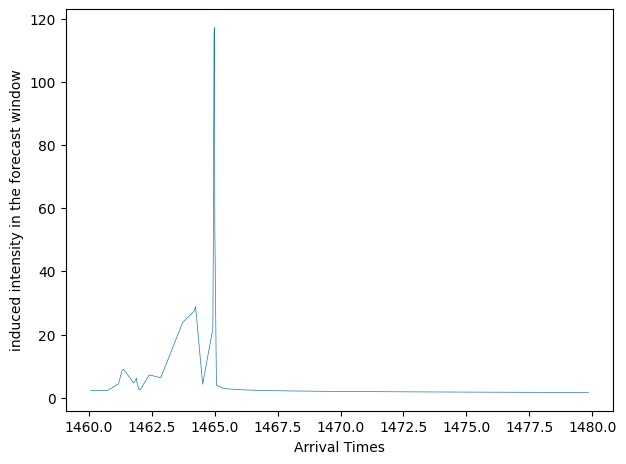

In [200]:
f_intensity  = model.bg_model.intensity(test_batch)
mask = (test_batch.arrival_times >=  t_forecast) & (test_batch.arrival_times <= t_forecast + duration)
f_intensity_sel = f_intensity[mask]
plt.xlabel('Arrival Times')
plt.ylabel('induced intensity in the forecast window')
plt.tight_layout()
plt.plot(test_batch.arrival_times[mask].reshape(-1).detach().cpu().numpy(), 
         f_intensity_sel.reshape(-1).detach().cpu().numpy(),
          linewidth=0.5,
         color='tab:blue')


In [167]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [201]:
model.nll_loss(train_batch)

f_intensity max:     1343.411865234375, h_intensity max: 57539.44921875
nll_bg mean: -3900.83154296875, nll_total mean: -45595.5078125


tensor([[-61.2843]], device='cuda:0', grad_fn=<DivBackward0>)

In [ ]:
set_seed(4) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

In [170]:
all_forecasts

[Sequence(
   inter_times: [896],
   arrival_times: [895],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [895]
 ),
 Sequence(
   inter_times: [861],
   arrival_times: [860],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [860]
 ),
 Sequence(
   inter_times: [823],
   arrival_times: [822],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [822]
 ),
 Sequence(
   inter_times: [867],
   arrival_times: [866],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [866]
 ),
 Sequence(
   inter_times: [909],
   arrival_times: [908],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [908]
 ),
 Sequence(
   inter_times: [930],
   arrival_times: [929],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [929]
 ),
 Sequence(
   inter_times: [965],
   arrival_times: [964],
   t_start: 1460.0,
   t_end: 1480.0,
   t_nll_start: 1460.0,
   mag: [964]
 ),
 Sequence(
   inter_times: 

In [171]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 145, 146, 147, 148, 149, 150, 151, 152, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 22

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [172]:
# importlib.reload(src.utils.visualization)

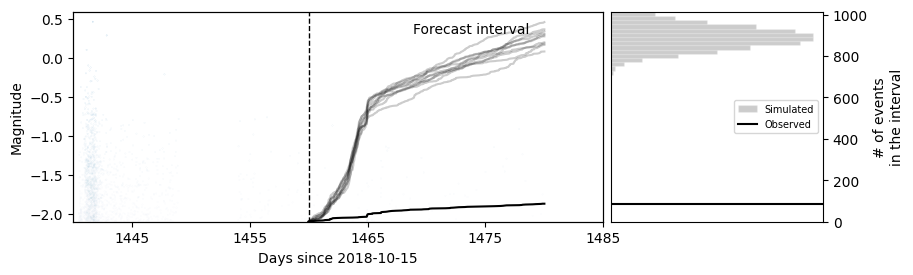

In [173]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [174]:
import  src.utils.catalog_tests as catalog_tests

In [175]:
test_seq

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 1428.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92192, 1],
  time_series_times: [92192]
)

N-test

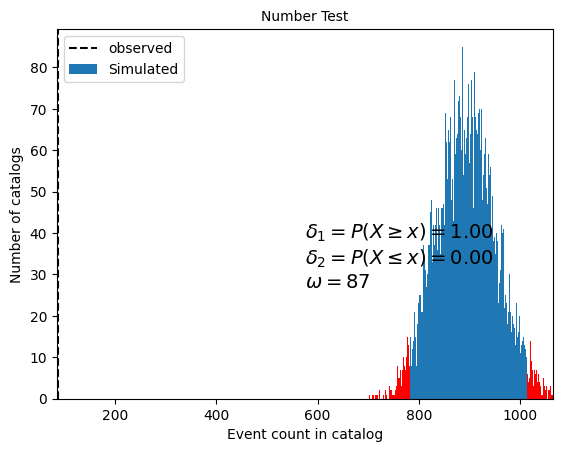

In [176]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [177]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [178]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


IndexError: index -1 is out of bounds for axis 0 with size 0

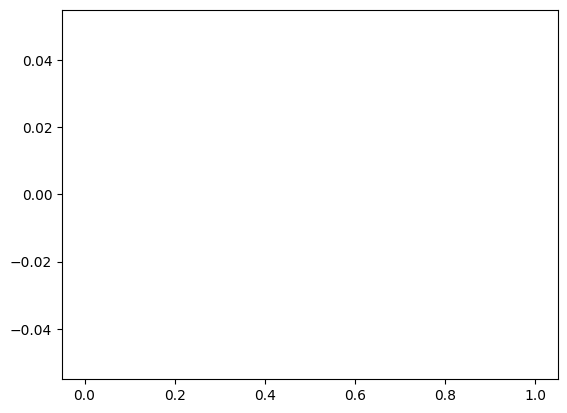

In [179]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')